# Object Detection with Deep Learning using YOLOv5

## Project Overview

This project implements an object detection system using the YOLOv5 deep learning framework.

The system is trained using the COCO128 dataset and uses a pretrained YOLOv5s model as the starting point. After training, the resulting model is used to detect multiple objects in a new street-scene image.

The project demonstrates the complete workflow of:

- Deep learning environment setup
- YOLOv5 installation
- Dataset preparation
- Pretrained model inference
- Model training
- Model evaluation
- Object detection on a new image

## Objectives

The main objectives of this project are:

1. To understand the fundamentals of object detection using deep learning.
2. To implement the YOLOv5 object detection framework in Google Colab.
3. To perform object detection using a pretrained YOLOv5 model.
4. To fine-tune the pretrained YOLOv5s model using the COCO128 dataset.
5. To evaluate the trained model using precision, recall, mAP@0.5, and mAP@0.5:0.95.
6. To perform object detection on a new image using the trained model.
7. To understand bounding boxes, confidence scores, IoU, and Non-Maximum Suppression (NMS).

## 1. Environment Setup

The project was implemented in Google Colab using Python and PyTorch.

A GPU runtime was enabled to accelerate the deep learning computations. The available GPU was a Tesla T4.

The main software components used in this project are:

- Google Colab
- Python
- PyTorch
- YOLOv5
- CUDA-enabled GPU
- COCO128 dataset

In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


## 2. YOLOv5 Installation

YOLOv5 was used as the object detection framework for this project.

The YOLOv5 repository was cloned into the Google Colab environment, and the required Python dependencies were installed before performing inference and training.

YOLOv5 provides the required components for:

- Model loading
- Object detection
- Model training
- Validation
- Non-Maximum Suppression (NMS)
- Detection result visualization

In [7]:
!git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 18764, done.
remote: Counting objects: 100% (322/322), done.
remote: Compressing objects: 100% (191/191), done.
remote: Total 18764 (delta 260), reused 131 (delta 131), pack-reused 18442 (from 4)
Receiving objects: 100% (18764/18764), 17.80 MiB | 20.07 MiB/s, done.
Resolving deltas: 100% (12763/12763), done.


In [8]:
%cd yolov5

/content/yolov5


In [9]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.4 MB/s eta 0:00:00


## 3. Pretrained Model and Initial Detection

Before training, the pretrained YOLOv5s model was used to perform an initial object detection test.

The pretrained weights (`yolov5s.pt`) were used on the sample images provided with the YOLOv5 repository.

This step verifies that the YOLOv5 environment, pretrained model, and detection pipeline are working correctly.

The detection output contains:

- Bounding boxes showing the location of detected objects
- Class labels identifying the objects
- Confidence scores indicating the model's confidence in each prediction

In [10]:
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source data/images

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
detect: weights=['yolov5s.pt'], source=data/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 225MB/s]

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
image 1/2 /content/y

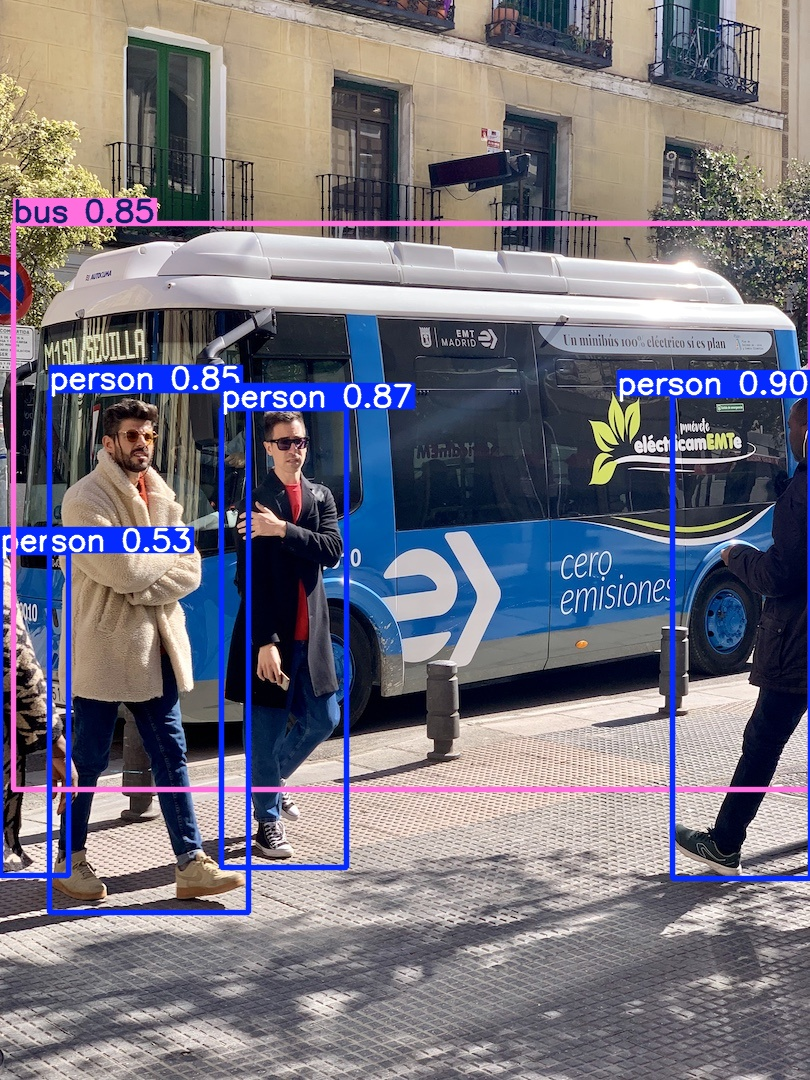

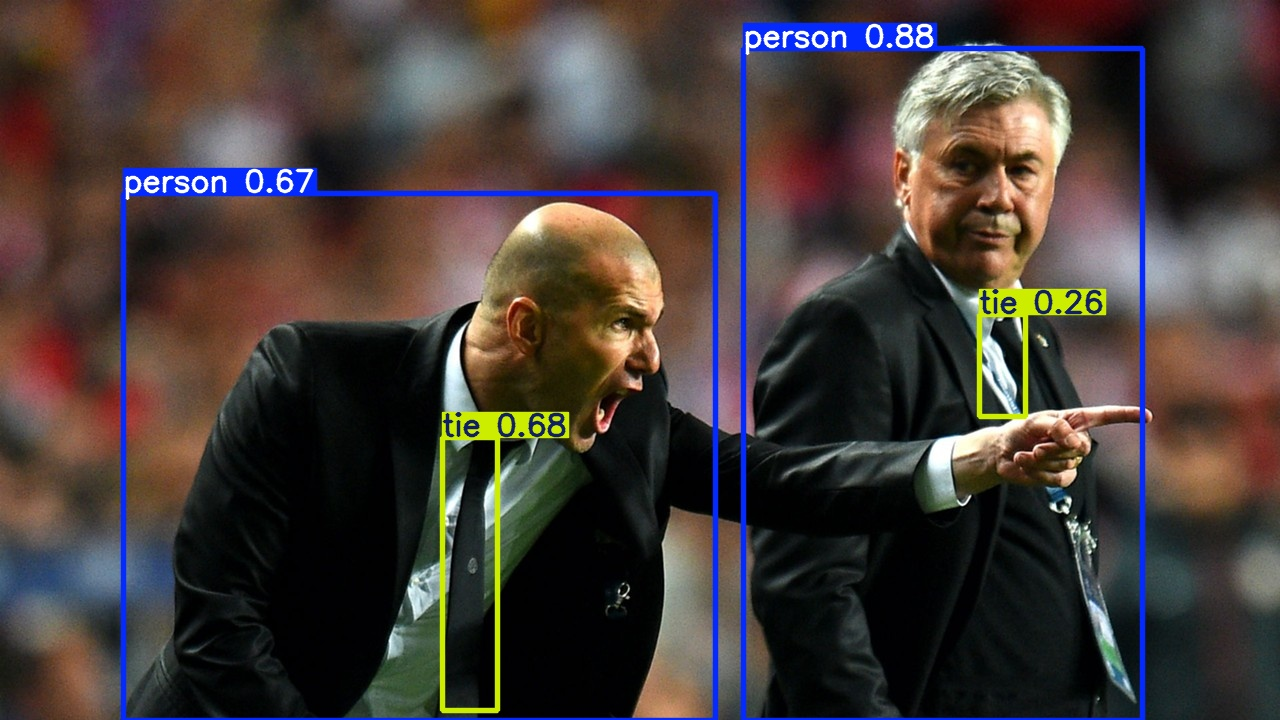

In [12]:
from IPython.display import Image, display

display(Image(filename='runs/detect/exp/bus.jpg'))
display(Image(filename='runs/detect/exp/zidane.jpg'))

## 4. Dataset – COCO128

The COCO128 dataset was used for training the YOLOv5 model.

COCO128 is a small subset of the COCO dataset containing 128 images and 80 object classes.

The dataset contains common object categories such as:

- Person
- Bicycle
- Car
- Motorcycle
- Bus
- Truck
- Traffic light
- Backpack
- Handbag
- And other COCO object categories

The dataset configuration file (`coco128.yaml`) specifies the dataset paths and the 80 class names used by YOLOv5.

### Dataset Configuration

- **Dataset:** COCO128
- **Number of images:** 128
- **Number of classes:** 80
- **Training image size:** 640 × 640
- **Validation image size:** 640 × 640

### Important Note

For this project demonstration, the COCO128 configuration used the same image directory for both training and validation. Therefore, the reported validation metrics should be interpreted as results from this configured evaluation setup rather than as an independent test-set performance estimate.

## 5. Model Training

The pretrained YOLOv5s model was fine-tuned using the COCO128 dataset.

Transfer learning was used by starting from the pretrained `yolov5s.pt` weights rather than training the model from scratch.

### Training Configuration

| Parameter | Value |
|---|---|
| Model | YOLOv5s |
| Dataset | COCO128 |
| Image Size | 640 × 640 |
| Batch Size | 16 |
| Number of Epochs | 5 |
| Optimizer | SGD |
| Initial Weights | `yolov5s.pt` |
| GPU | Tesla T4 |

During training, the model learns to predict object locations, objectness scores, and class labels. The training process updates the model weights using backpropagation and gradient-based optimization.

The trained model produces two important weight files:

- `best.pt` – the best-performing model checkpoint during training
- `last.pt` – the model checkpoint from the final training epoch

In [13]:
!python train.py \
    --img 640 \
    --batch 16 \
    --epochs 5 \
    --data data/coco128.yaml \
    --weights yolov5s.pt \
    --name my_yolov5_project

WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=data/coco128.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=5, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=my_yolov5_project, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-

## 6. Training Results

The YOLOv5s model was trained for 5 epochs using the COCO128 dataset.

The training process recorded the bounding-box loss, objectness loss, classification loss, precision, recall, and mean Average Precision (mAP).

The training curves show the change in model performance and losses across the five epochs.

### Training Observations

- Training and validation losses generally decreased during training.
- Precision increased from approximately 0.706 to 0.768.
- Recall increased from approximately 0.601 to 0.665.
- mAP@0.5 increased from approximately 0.683 to 0.758.
- mAP@0.5:0.95 increased from approximately 0.453 to 0.514.

The trained model generated `best.pt` and `last.pt` weight files for subsequent evaluation and inference.

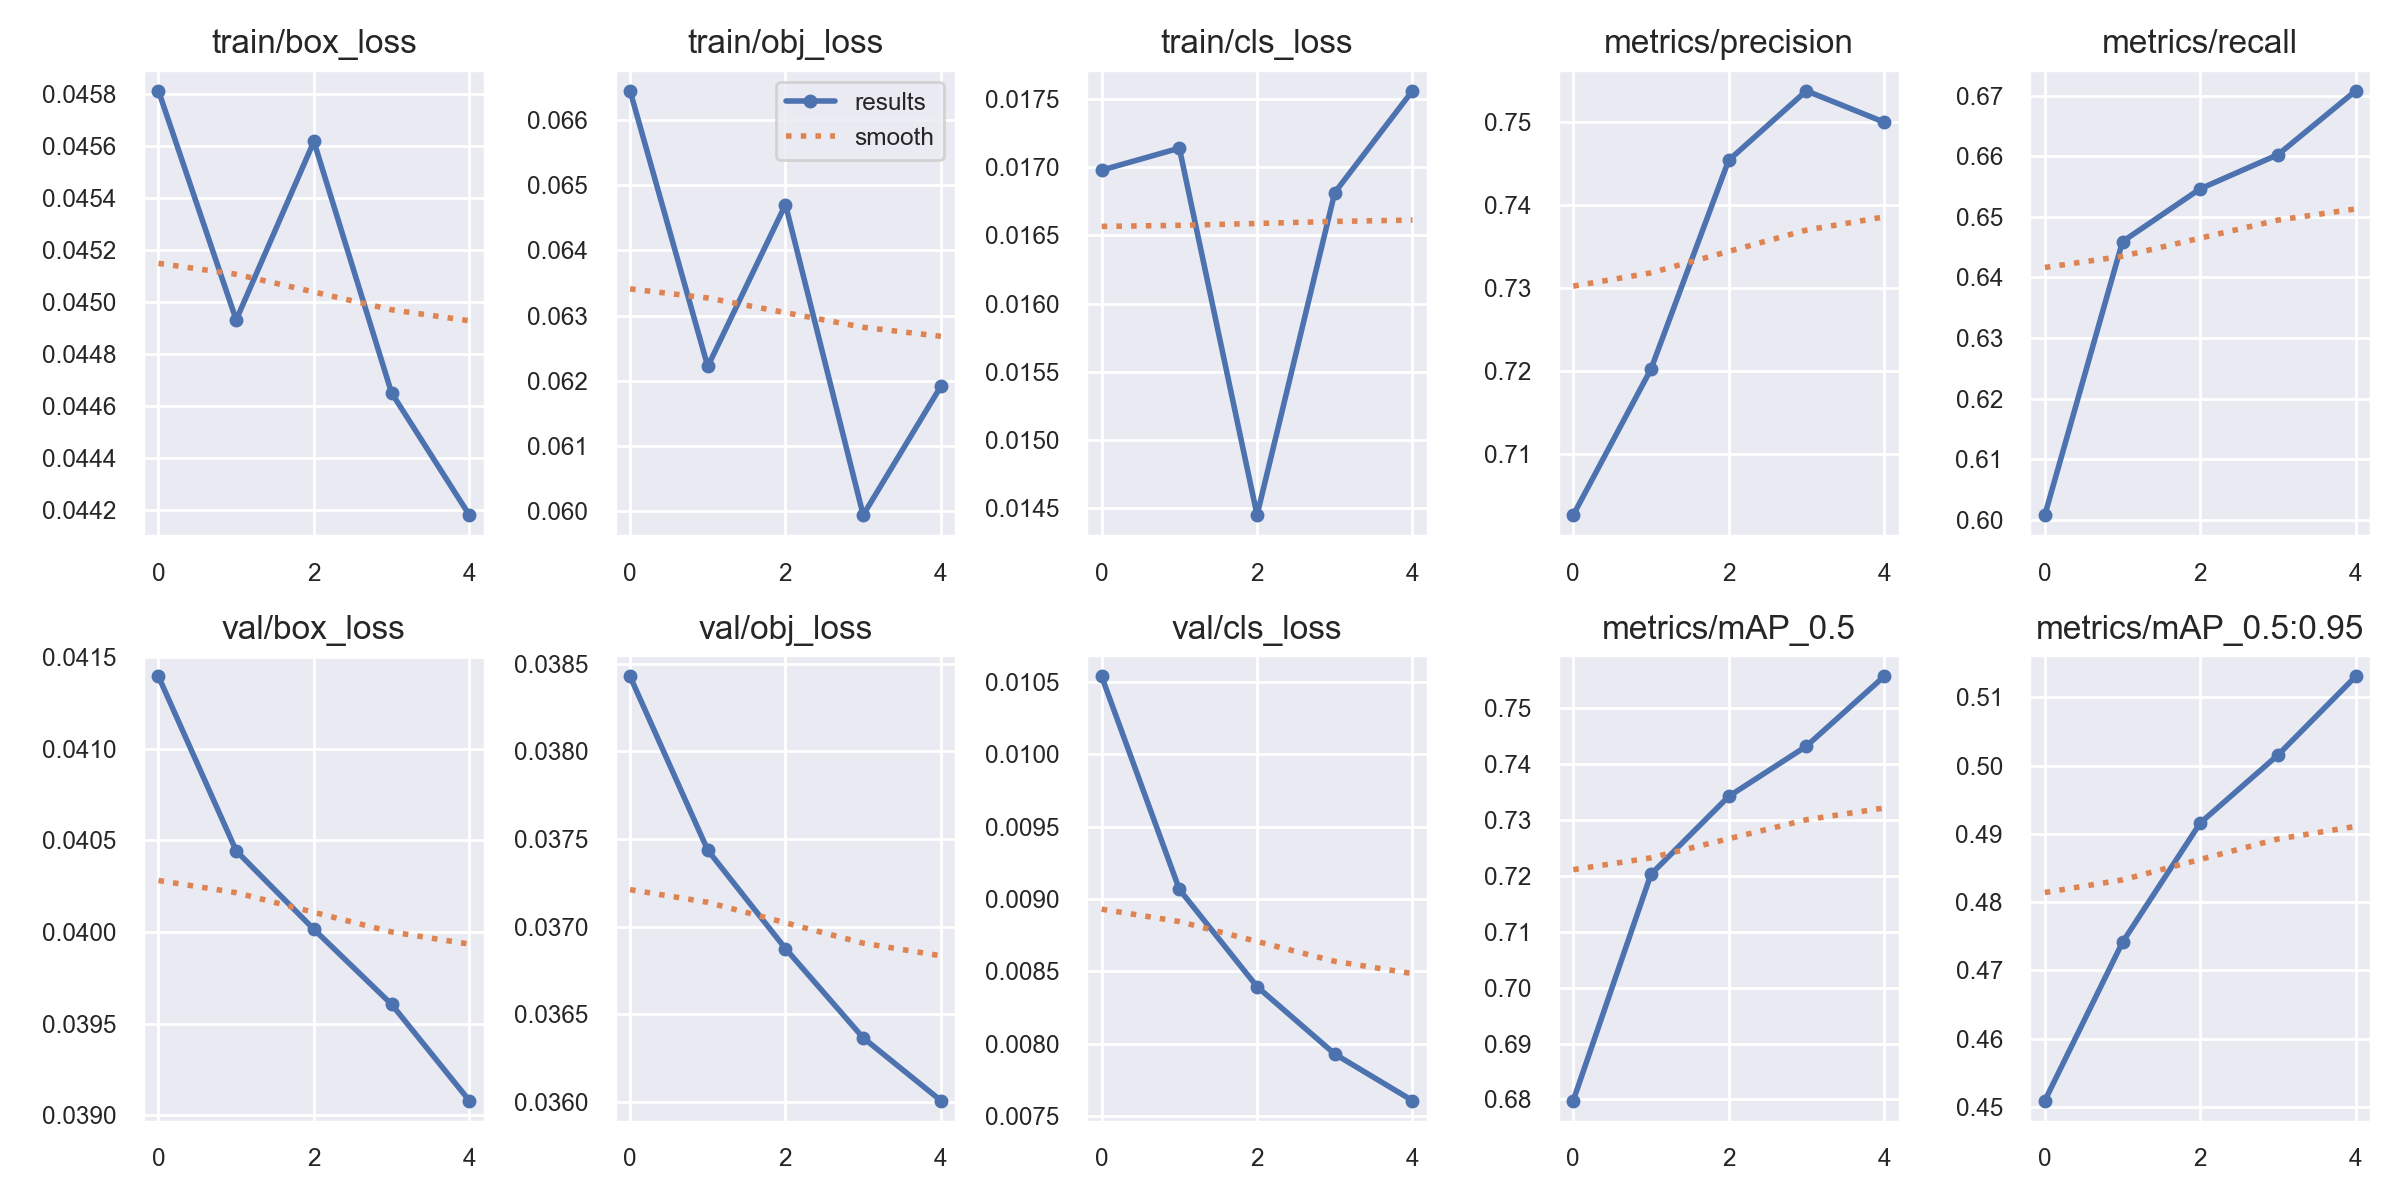

In [14]:
from IPython.display import Image, display

display(Image(filename='runs/train/my_yolov5_project/results.png'))

## 7. Evaluation Metrics

The trained YOLOv5s model was evaluated using standard object detection metrics.

| Metric | Result |
|---|---:|
| Precision | 0.767 |
| Recall | 0.665 |
| mAP@0.5 | 0.759 |
| mAP@0.5:0.95 | 0.515 |

### Metric Definitions

**Precision**

Precision measures how many of the objects predicted by the model were correct.

\[
Precision = \frac{TP}{TP + FP}
\]

**Recall**

Recall measures how many of the actual objects were successfully detected.

\[
Recall = \frac{TP}{TP + FN}
\]

**mAP@0.5**

Mean Average Precision calculated using an IoU threshold of 0.50.

**mAP@0.5:0.95**

Mean Average Precision averaged over IoU thresholds from 0.50 to 0.95.

### Evaluation Note

The COCO128 configuration used the same image directory for both training and validation. Therefore, these metrics should not be interpreted as an independent test-set measure of real-world generalization.

In [15]:
from google.colab import files

uploaded = files.upload()

Saving Busy City Intersection with Blue Bus.png to Busy City Intersection with Blue Bus.png


## 8. Final Object Detection on a New Image

The trained YOLOv5s model (`best.pt`) was used to perform object detection on a new street-scene image.

The image contains multiple real-world object categories. The model identifies the objects and displays their locations using bounding boxes along with the predicted class and confidence score.

This demonstrates the inference stage of the completed object detection pipeline.

In [22]:
!python detect.py \
    --weights runs/train/my_yolov5_project/weights/best.pt \
    --img 640 \
    --conf 0.25 \
    --source "Busy City Intersection with Blue Bus.png" \
    --name final_street_detection

detect: weights=['runs/train/my_yolov5_project/weights/best.pt'], source=Busy City Intersection with Blue Bus.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=final_street_detection, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
image 1/1 /content/yolov5/Busy City Intersection with Blue Bus.png: 448x640 6 persons, 1 bicycle, 5 cars, 1 motorcycle, 1 bus, 1 truck, 4 traffic lights, 5 backpacks, 2 handbags, 40.8ms
Speed: 0.7ms pre-process, 40.8ms inference, 85.3ms NMS per image at shape (1, 3, 640, 640

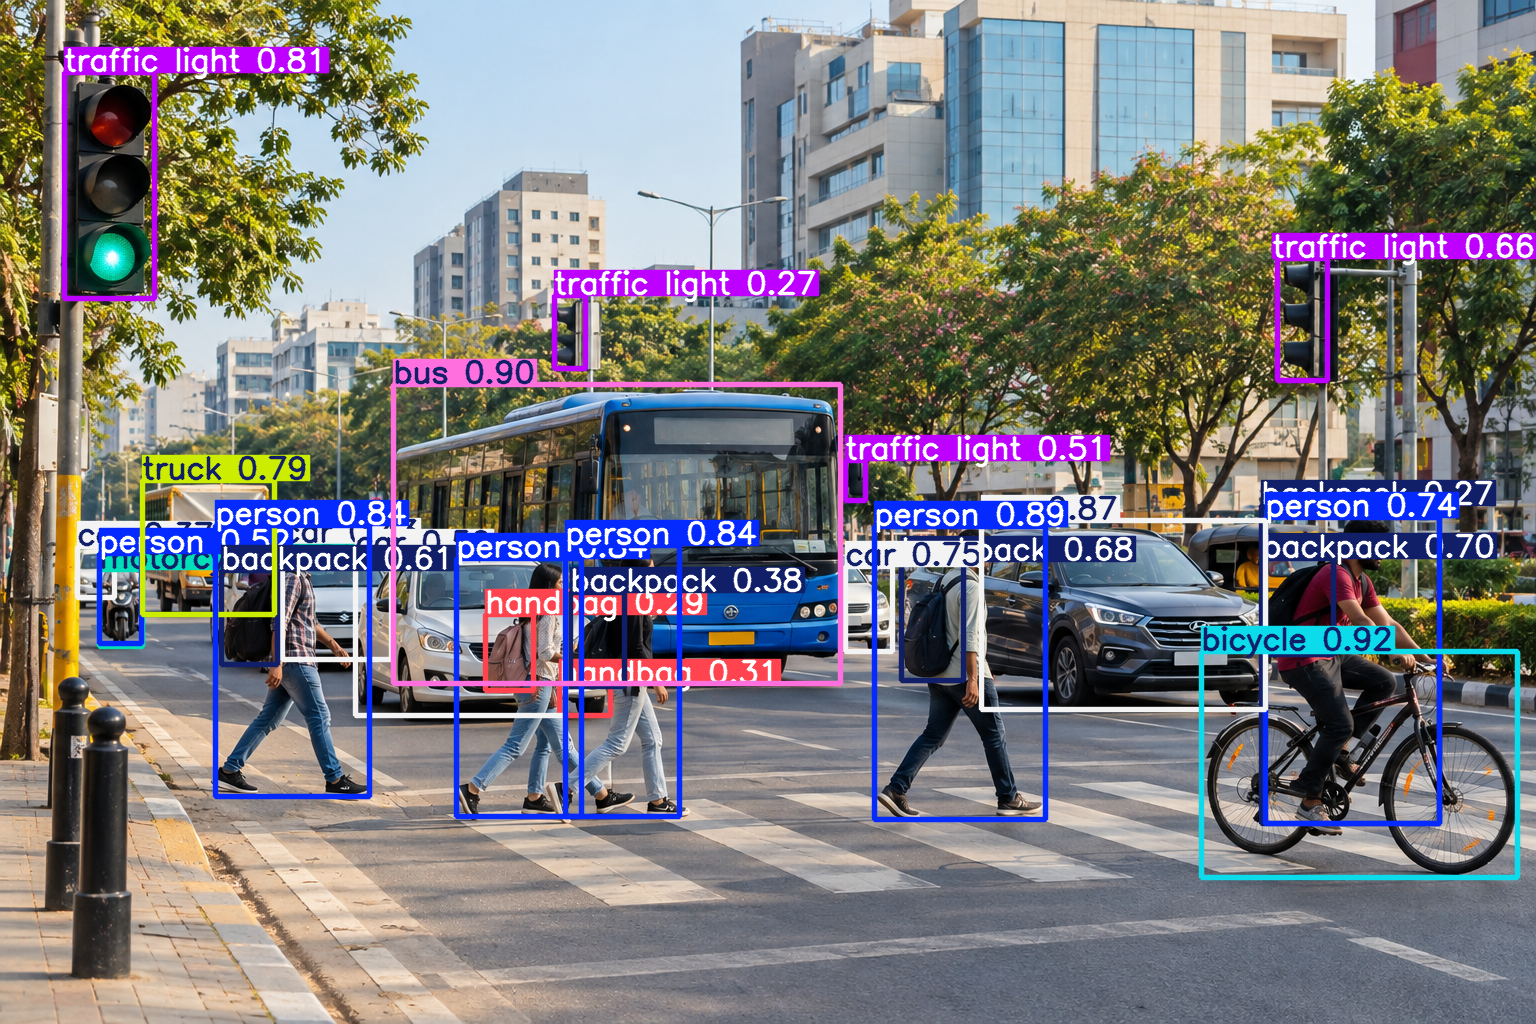

In [23]:
from IPython.display import Image, display

display(Image(
    filename='runs/detect/final_street_detection/Busy City Intersection with Blue Bus.png'
))

## 9. Limitations

The following limitations were observed in this project:

1. The COCO128 dataset contains only 128 images, so it is relatively small for training a general object detection model.
2. The model was trained for only 5 epochs because of the limited experimental time and computational resources.
3. The COCO128 configuration used the same image directory for both training and validation, so the validation results should not be treated as an independent test-set evaluation.
4. The pretrained COCO classes limit the types of objects that can be detected.
5. The final street image was used only for inference and was not part of the training dataset.

## 10. Future Scope

The project can be improved in several ways:

- Use a larger and more diverse dataset.
- Create a custom dataset with application-specific object classes.
- Train the model for more epochs.
- Use a separate independent test dataset.
- Perform hyperparameter optimization.
- Extend the system to real-time video object detection.
- Deploy the trained model in a web or mobile application.
- Improve detection performance for small and partially occluded objects.

## 11. Conclusion

This project demonstrated the complete workflow of object detection using deep learning and YOLOv5.

A pretrained YOLOv5s model was fine-tuned using the COCO128 dataset in Google Colab with a Tesla T4 GPU. The model was trained for 5 epochs and evaluated using precision, recall, mAP@0.5, and mAP@0.5:0.95.

The trained `best.pt` model was successfully used to perform inference on a new street-scene image. The model detected multiple COCO object categories and displayed their bounding boxes, class labels, and confidence scores.

Through this project, the concepts of object detection, transfer learning, bounding boxes, confidence scores, IoU, NMS, model training, and evaluation metrics were practically demonstrated.